[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/04_evaluation.ipynb)

# 04 — Results and How Far to Trust Them

**Question.** Which tilt configuration should be recommended, what does it change on the network, and how
robust is that conclusion?

**Inputs.** The newest run of each method and seed under `outputs/optim/`, the current radio map, and the
processed tables. **Outputs.** `reports/tables/04_evaluation/` and `reports/figures/04_evaluation/`.
No GPU is needed. Every table and figure is built by `src/evaluation/run.py`, the same code `task evaluate` runs.
The Multi-Agent Reinforcement Learning arm is not implemented, so the comparison covers TuRBO and the two baselines.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation.export import save_table
from src.evaluation.run import evaluate
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/04_evaluation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/04_evaluation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

## 1. Comparability

Runs are compared only if they share the scenario, grid, solver settings, bands and KPI definition.

In [3]:
results = evaluate(cfg, in_colab=IN_COLAB)
checks = results["comparability_checks"]
print(f"{int(checks['Holds'].sum())} of {len(checks)} comparability checks hold")

21 of 21 comparability checks hold


## 2. KPI Scoreboard

Best configuration of each method, averaged over seeds, against the current configuration. A change within a KPI's
tolerance (`configs/kpi.yaml`) is reported as a tie.

,Method,KPI,Direction,Seeds,Current configuration,Mean,Standard deviation,95% CI lower,95% CI upper,Mean change,Tolerance,Verdict
0,Random search,Coverage hole rate,minimise,1,0.1618,0.1549,NaN,NaN,NaN,-0.0069,0.002,better
1,Random search,Co-band overlap rate,minimise,1,0.3531,0.3578,NaN,NaN,NaN,0.0047,0.001,worse
2,Random search,Served UE ratio,maximise,1,0.7758,0.8208,NaN,NaN,NaN,0.0450,0.001,better
3,Random search,Weak coverage rate,minimise,1,0.3491,0.3064,NaN,NaN,NaN,-0.0427,0.004,better
4,Random search,Weighted score,maximise,1,-0.5041,-0.3579,NaN,NaN,NaN,0.1462,NaN,
5,Rule-based sweep,Coverage hole rate,minimise,1,0.1618,0.1516,NaN,NaN,NaN,-0.0102,0.002,better
6,Rule-based sweep,Co-band overlap rate,minimise,1,0.3531,0.3615,NaN,NaN,NaN,0.0084,0.001,worse
7,Rule-based sweep,Served UE ratio,maximise,1,0.7758,0.8279,NaN,NaN,NaN,0.0521,0.001,better
8,Rule-based sweep,Weak coverage rate,minimise,1,0.3491,0.2958,NaN,NaN,NaN,-0.0533,0.004,better
9,Rule-based sweep,Weighted score,maximise,1,-0.5041,-0.3310,NaN,NaN,NaN,0.1731,NaN,


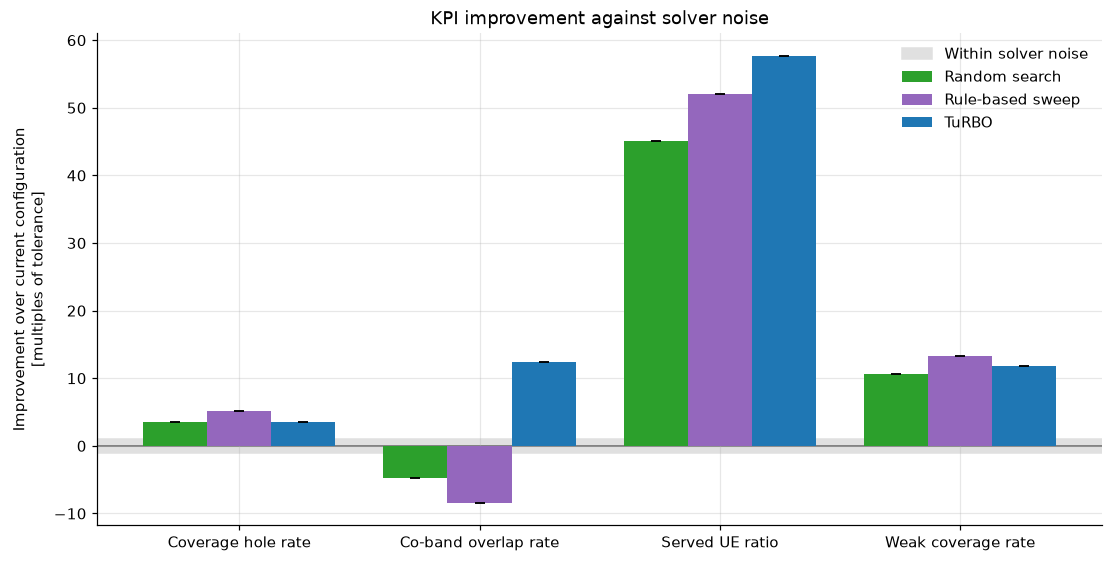

In [4]:
display(results["kpi_scoreboard"])
display(results["kpi_improvement_vs_tolerance"])

**Observations.** _To be written._

## 3. Did the Search Matter?

Each run's best score against the typical candidate it evaluated, and TuRBO against random search paired by seed.

In [5]:
display(results["winner_vs_candidates"])
display(results["paired_gain_turbo_vs_random"])

,Method,Seed,Current configuration,"Initial design, median score","All candidates, median score","All candidates, 90th percentile score",Best score found
0,Random search,42,-0.5041,-0.4317,-0.4358,-0.3981,-0.3579
1,Rule-based sweep,42,-0.5041,NaN,-0.3970,-0.3344,-0.3310
2,TuRBO,42,-0.5041,-0.4317,-0.3310,-0.2970,-0.2766


,Method,Reference,Seed pairs,Mean score gain,95% CI lower,95% CI upper,Seeds won,Wilcoxon p-value
0,TuRBO,Random search,1,0.0814,NaN,NaN,1,NaN


**Observations.** _To be written._

## 4. Is the Result Robust?

Whether the chosen configurations change under other KPI weights, and whether their improvement survives other
ray-tracer seeds.

In [6]:
display(results["weight_sensitivity"])
for name in ("solver_noise", "retraced_gain"):
    if name in results:
        display(results[name])
    else:
        print(f"{name}: not available; run section 3 of notebook 03b")

,Weighting,Method,Seeds,Mean best score,Rank,Share with unchanged best configuration
0,configured,Random search,1,-0.3579,3,1.0
1,configured,Rule-based sweep,1,-0.3310,2,1.0
2,configured,TuRBO,1,-0.2766,1,1.0
3,equal,Random search,1,0.0017,3,1.0
4,equal,Rule-based sweep,1,0.0190,2,0.0
5,equal,TuRBO,1,0.0359,1,1.0
6,coverage_only,Random search,1,-0.4550,3,0.0
7,coverage_only,Rule-based sweep,1,-0.4451,1,0.0
8,coverage_only,TuRBO,1,-0.4512,2,0.0
9,hole_only,Random search,1,-0.1533,3,0.0


,KPI,Tolerance,"Solver noise, standard deviation",Tolerance / solver noise
0,Coverage hole rate,0.002,0.0008,2.5807
1,Co-band overlap rate,0.001,0.0004,2.2316
2,Served UE ratio,0.001,0.0063,0.1577
3,Weak coverage rate,0.004,0.0006,6.3355


,Configuration,Solver seeds,Mean score gain,95% CI lower,95% CI upper,Share of solver seeds improved
0,random seed 42,5,0.1349,0.1272,0.1426,1.0
1,rule seed 42,5,0.1654,0.1550,0.1759,1.0
2,turbo seed 42,5,0.2214,0.2085,0.2343,1.0


**Observations.** _To be written._

## 5. Where Coverage Changed

Change in best-server signal strength for each method's best configuration, and the coverage holes the recommended
configuration closes or opens.

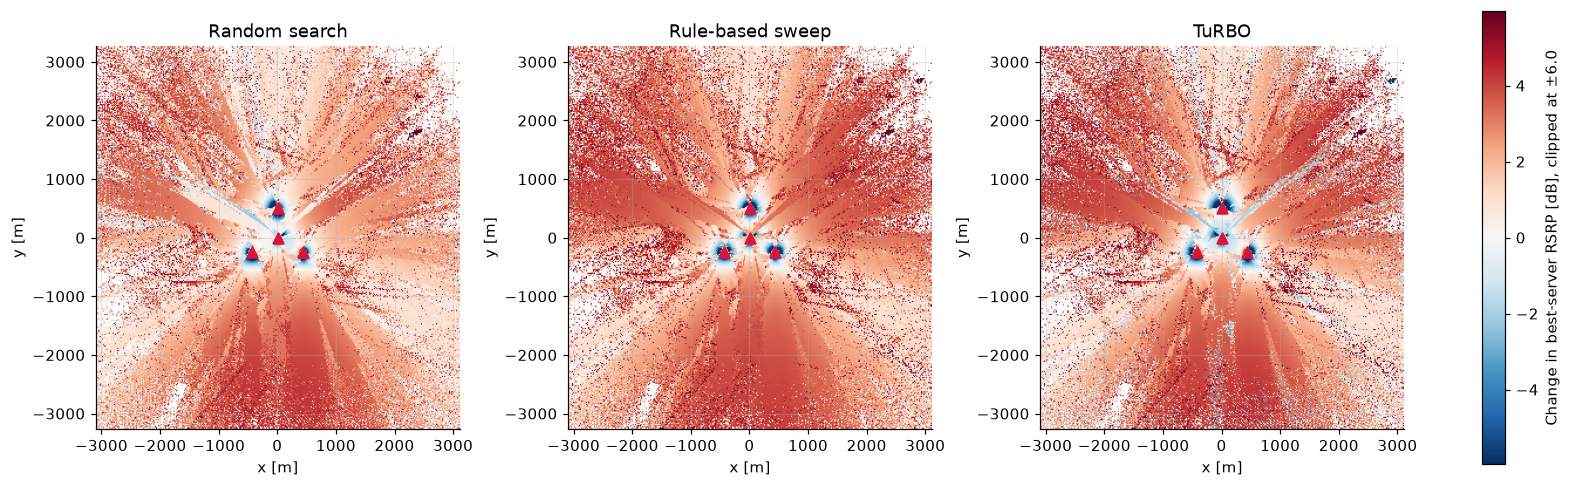

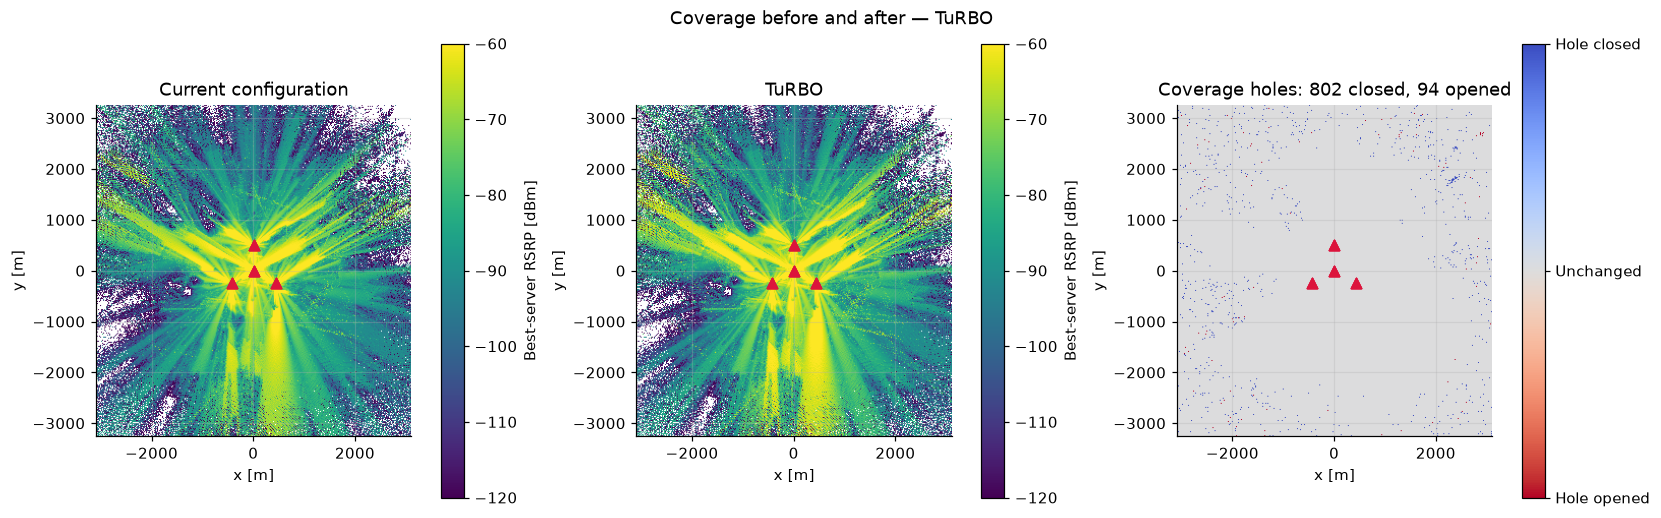

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand,TuRBO: Share of area,TuRBO: Share of demand
0,hole,0.1619,0.0000,0.1549,0.0000,0.1516,0.0000,0.1548,0.0029
1,weak,0.3491,0.7668,0.3064,0.7058,0.2958,0.6961,0.3021,0.6997
2,good,0.4890,0.2332,0.5387,0.2942,0.5526,0.3039,0.5430,0.2974


In [7]:
display(results["rsrp_change_maps"])
display(results["coverage_before_after"])
display(results["coverage_by_area_and_demand"])

**Observations.** _To be written._

## 6. Capacity Impact

Capacity settings are placeholders, so read the direction of change rather than absolute values.

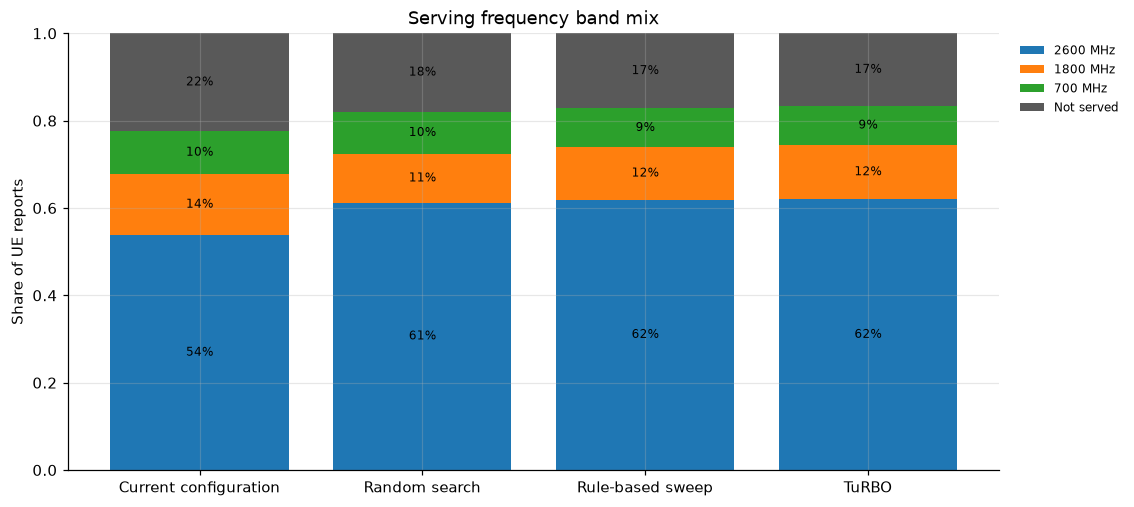

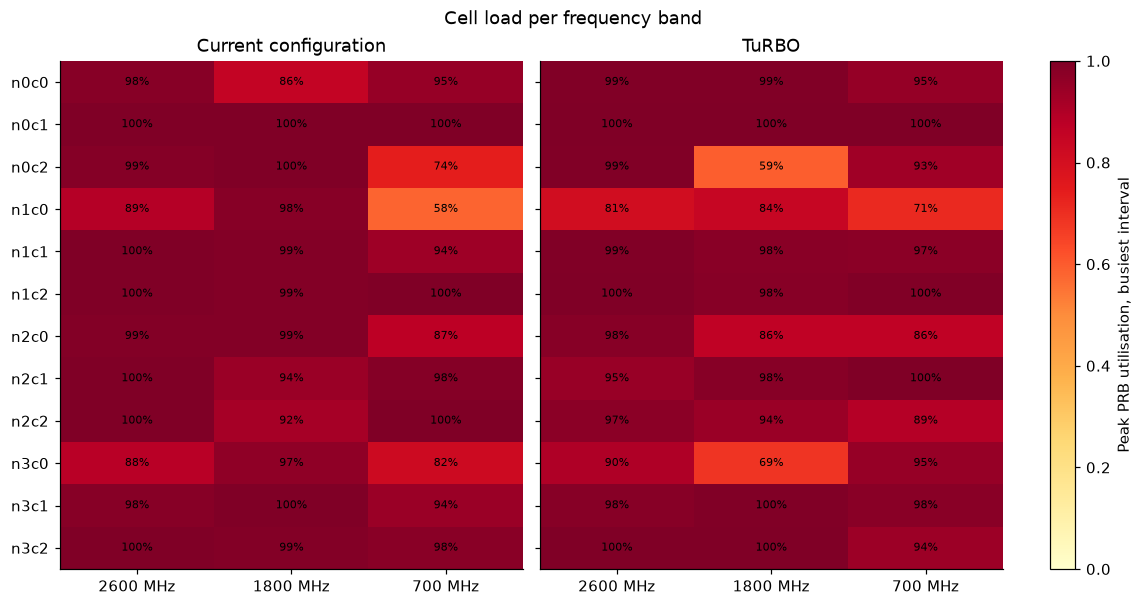

,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,9929.0,0.2242,-0.7732,5.0763,53.5043,0.5377,0.1404,0.0977
1,Random search,9929.0,0.1792,0.1442,6.7541,44.0911,0.6124,0.1112,0.0972
2,Rule-based sweep,9929.0,0.1721,-0.2909,6.0056,47.9352,0.6194,0.1198,0.0887
3,TuRBO,9929.0,0.1665,-0.0656,6.3249,46.2315,0.6198,0.1249,0.0888


In [8]:
display(results["serving_band_mix"])
display(results["cell_band_utilisation"])
display(results["ue_service_summary"])

**Observations.** _To be written._

## 7. Recommended Tilt Changes

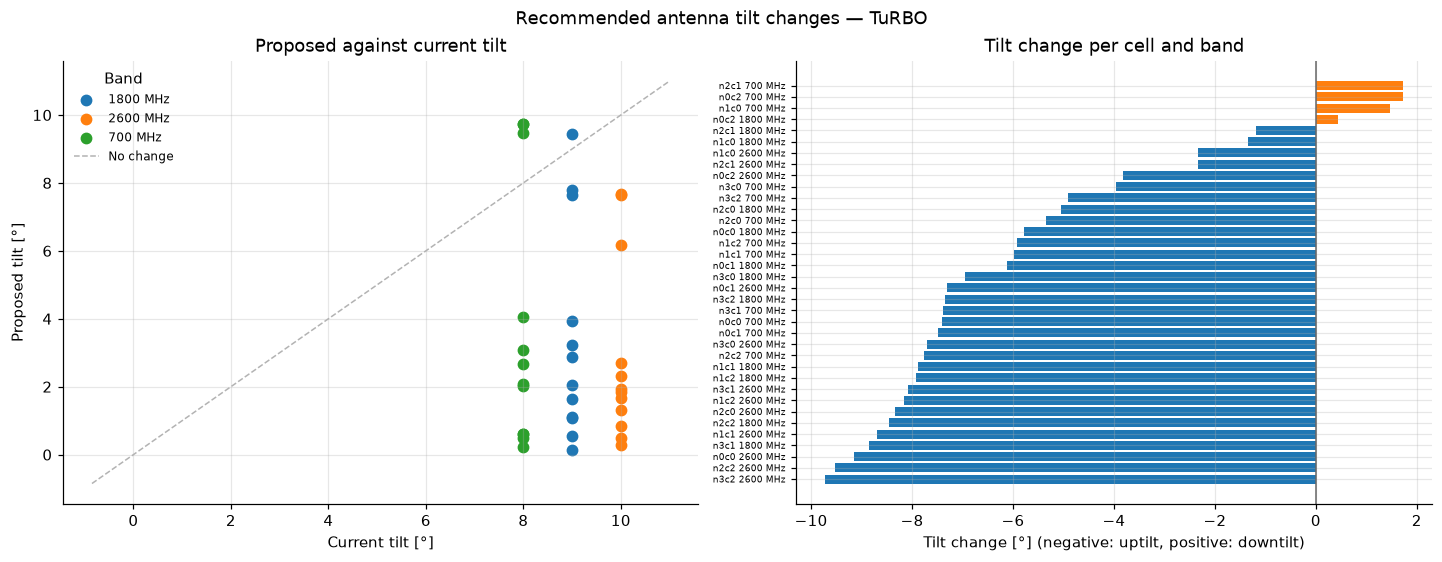

,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,5.6116,8.8503,-5.538
1,2600 MHz,12,12,7.0960,9.7181,-7.096
2,700 MHz,12,12,5.0880,7.7664,-4.269


,Site,Cell,Azimuth [°],Band,Current tilt [°],Proposed tilt [°],Tilt change [°],"Served reports, before","Peak PRB utilisation, before",Median SINR before [dB],"Served reports, after","Peak PRB utilisation, after",Median SINR after [dB],"Served reports, change","Peak PRB utilisation, change",Median SINR change [dB]
0,n0,n0c1,150.0,2600 MHz,10.0,2.6987,-7.3013,1400,1.0000,4.9351,1691,1.0000,7.3190,291,2.0202e-06,2.3838
1,n3,n3c2,270.0,2600 MHz,10.0,0.2819,-9.7181,1304,0.9991,5.0616,1537,0.9998,5.9690,233,6.7684e-04,0.9074
2,n3,n3c1,150.0,2600 MHz,10.0,1.9189,-8.0811,288,0.9809,2.0814,388,0.9837,4.6526,100,2.8384e-03,2.5711
3,n1,n1c2,270.0,2600 MHz,10.0,1.8362,-8.1638,1365,0.9975,6.6377,1462,0.9999,7.7133,97,2.3949e-03,1.0756
4,n1,n1c2,270.0,1800 MHz,9.0,1.0816,-7.9184,342,0.9905,5.5800,259,0.9834,7.4084,-83,-7.0395e-03,1.8284
5,n1,n1c2,270.0,700 MHz,8.0,2.0882,-5.9118,231,0.9969,13.4828,149,0.9952,13.6739,-82,-1.7722e-03,0.1911
6,n0,n0c1,150.0,1800 MHz,9.0,2.8889,-6.1111,539,0.9990,5.1834,464,0.9979,5.9382,-75,-1.0368e-03,0.7548
7,n1,n1c1,150.0,2600 MHz,10.0,1.3108,-8.6892,246,0.9984,0.4258,314,0.9941,2.3886,68,-4.3237e-03,1.9628
8,n0,n0c1,150.0,700 MHz,8.0,0.5042,-7.4958,501,0.9990,11.0330,449,0.9979,12.6329,-52,-1.0560e-03,1.5999
9,n3,n3c1,150.0,700 MHz,8.0,0.6169,-7.3831,77,0.9436,6.1244,118,0.9802,8.9399,41,3.6556e-02,2.8155


In [9]:
display(results["tilt_movement"])
display(results["tilt_movement_summary"])
display(results["cell_impact"])

**Observations.** _To be written._

## 8. Search Cost and Progress

,Method,Seed,Run,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Served UE ratio,Weak coverage rate,Weighted score,KPIs improved,KPIs worsened
0,Random search,42,2026-09-15_14-28-43,145,125,11.1659,13.1871,0.1549,0.3578,0.8208,0.3064,-0.3579,3,1
1,Rule-based sweep,42,2026-09-15_14-41-55,27,11,0.8256,1.0564,0.1516,0.3615,0.8279,0.2958,-0.3310,3,1
2,TuRBO,42,2026-09-15_14-43-07,145,142,5.5821,8.5387,0.1548,0.3407,0.8335,0.3021,-0.2766,4,0


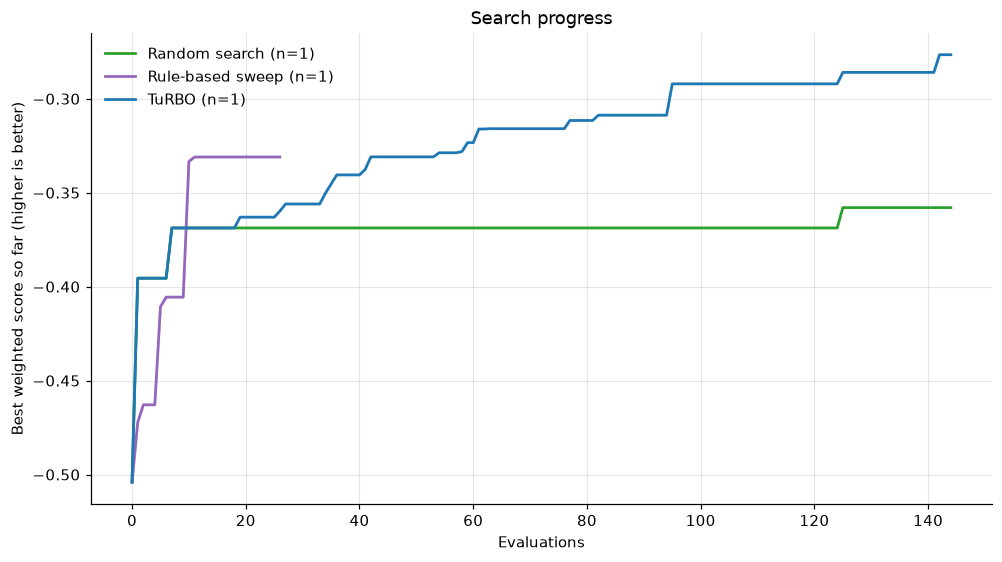

In [10]:
display(results["method_cost"])
display(results["search_progress"])

**Observations.** _To be written._

## 9. Threats to Validity

| # | Threat | Evidence | Status |
|---|---|---|---|
| 1 | One scenario: every configuration is tuned and scored on the same city and population, so no result measures generalisation | — | Open: held-out scenarios are not implemented |
| 2 | Winner's curse: the best of many evaluations under one solver seed is biased upward | Section 4, re-traced gain | Mitigated |
| 3 | Weak reference: the current configuration uses identical default tilts, and the 2600 MHz tilt starts at its upper bound | Section 3, winner against candidates; notebook 02, decision variables | Mitigated |
| 4 | Too few runs to compare methods | Sections 2 and 3, intervals and paired test over seeds | Mitigated; power remains limited by the number of seeds |
| 5 | The weighted score depends on judgement weights that are not normalised | Section 4, weight sensitivity | Mitigated |
| 6 | Hole and weak rates count area, including area without users | Section 5, coverage by area and by demand | Reported |
| 7 | The served ratio relies on placeholder capacity settings; UEs no cell reaches are excluded before it is computed | Notebook 01, data quality | Open |
| 8 | Physical simplifications: full-load SINR, Shannon rate without MCS, no calibration against field measurements, reported RSRP below the 3GPP reporting range | Notebook 01, data quality | Open |
| 9 | The project title names Multi-Agent Reinforcement Learning, which is not implemented | — | Open |
| 10 | The rule-based sweep is not budget-matched; tilt movement and operational cost are not constrained | Sections 7 and 8 | Reported |